## NF generated top mass reconstruction

In [8]:
import sys
sys.path.insert(0, "./pydeps")

import torch
import numpy as np
import random
import normflows as nf
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
import tqdm
import pandas as pd
from scipy.stats import ks_2samp
import torch.nn as nn
# from datasets import load_dataset

%config InlineBackend.figure_format = 'svg'

from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('svg')

In [7]:
!python3 -m pip install

In [9]:
seed = 121

random.seed(seed)
np.random.seed(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.use_deterministic_algorithms(True)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

g = torch.Generator()
g.manual_seed(seed)

In [10]:
# Top Mass Reconstruction Algorithm
def reconstruct_top_mass(events: pd.DataFrame):
    if len(events) < 6:
        return np.nan

    b_jets, W1, W2 = split_jets(events)
    return top_mass(b_jets, W1, W2)

def inv_mass_2jets(jets_2x9: np.ndarray) -> float:
    E = np.sum(jets_2x9[:, 5])
    px = np.sum(jets_2x9[:, 6])
    py = np.sum(jets_2x9[:, 7])
    pz = np.sum(jets_2x9[:, 8])
    m2 = E**2 - px**2 - py**2 - pz**2
    return np.sqrt(max(m2, 0.0))

def top_mass(b_jets, W1, W2):
    # W masses
    m_jj1 = inv_mass_2jets(W1)
    m_jj2 = inv_mass_2jets(W2)

    m_bjj11 = np.sqrt((np.sum(W1[:, 5]) + b_jets[0][5]) ** 2
                      - (np.sum(W1[:, 6]) + b_jets[0][6]) ** 2
                      - (np.sum(W1[:, 7]) + b_jets[0][7]) ** 2
                      - (np.sum(W1[:, 8]) + b_jets[0][8]) ** 2)

    m_bjj12 = np.sqrt((np.sum(W2[:, 5]) + b_jets[0][5]) ** 2
                      - (np.sum(W2[:, 6]) + b_jets[0][6]) ** 2
                      - (np.sum(W2[:, 7]) + b_jets[0][7]) ** 2
                      - (np.sum(W2[:, 8]) + b_jets[0][8]) ** 2)

    m_bjj21 = np.sqrt((np.sum(W1[:, 5]) + b_jets[1][5]) ** 2
                      - (np.sum(W1[:, 6]) + b_jets[1][6]) ** 2
                      - (np.sum(W1[:, 7]) + b_jets[1][7]) ** 2
                      - (np.sum(W1[:, 8]) + b_jets[1][8]) ** 2)

    m_bjj22 = np.sqrt((np.sum(W2[:, 5]) + b_jets[1][5]) ** 2
                      - (np.sum(W2[:, 6]) + b_jets[1][6]) ** 2
                      - (np.sum(W2[:, 7]) + b_jets[1][7]) ** 2
                      - (np.sum(W2[:, 8]) + b_jets[1][8]) ** 2)

    m_W = 80.4
    sigma_W = 10
    sigma_teq = 25

    chi2_1 = (m_bjj11 - m_bjj21) ** 2 / (sigma_teq ** 2)
    chi2_2 = (m_bjj12 - m_bjj22) ** 2 / (sigma_teq ** 2)

    if chi2_1 < chi2_2:
        return (m_bjj11, m_bjj21, m_jj1, m_jj2)
    else:
        return (m_bjj12, m_bjj22, m_jj1, m_jj2)

# Split jets into b and light
def split_jets(events: pd.DataFrame):
    evts = events[['pt', 'pb', 'pc', 'pu', 'ptau', 'E', 'px', 'py', 'pz']].values
    b_jets = []
    W1 = []
    W2 = []

    # Rank jets by probability ratio and pick the top 2 to be b-jet candidates
    pb, pc, pu, ptau = evts[:, 1], evts[:, 2], evts[:, 3], evts[:, 4]
    disc = pb / (pc + pu + ptau)
    sorted_indices = np.argsort(disc)
    b1, b2 = sorted_indices[-2:]
    b_jets.append(evts[b1])
    b_jets.append(evts[b2])

    # Remove the b-jets
    evts = np.delete(evts, [b1, b2], axis=0)

    # Sort the rest events by pT and keep only the first 6 (if there are more than 6, otherwise do nothing)
    sorted_indices = np.argsort(evts[:, 0])[::-1]
    evts = evts[sorted_indices]
    if len(evts) > 6:
        evts = evts[:6]

    # Find disjoint pairs that minimizes total score
    min_indices = find_min_disjoint_pairs(evts)
    W1.append(evts[min_indices[0]])
    W1.append(evts[min_indices[1]])
    W2.append(evts[min_indices[2]])
    W2.append(evts[min_indices[3]])

    return np.array(b_jets), np.array(W1), np.array(W2), 

# Find disjoint pairs (i, j), (k, l) that minimizes total score S[i, j] + S[k, l]
def find_min_disjoint_pairs(evts: np.ndarray):
    n = len(evts)
    S = np.zeros((n, n))
    E, px, py, pz = evts[:, 5], evts[:, 6], evts[:, 7], evts[:, 8]
    
    # Iterate over all pairs and compute the score, store the scores in S
    for i in range(n - 1):
        for j in range(i + 1, n):
            m_ij = np.sqrt((E[i] + E[j]) ** 2 - (px[i] + px[j]) ** 2 - (py[i] + py[j]) ** 2 - (pz[i] + pz[j]) ** 2)
            m_W = 80.4
            sigma_W = 10
            S[i, j] = ((m_ij - m_W) ** 2) / (sigma_W ** 2)

    min_score_sum = float('inf')
    min_indices = [0, 0, 0, 0]
    for i in range(n - 1):
        for j in range(i + 1, n):
            for k in range(n - 1):
                for l in range(k + 1, n):
                    if i != k and j != l and i != l and j != k:
                        score_sum = S[i, j] + S[k, l]
                        if score_sum < min_score_sum:
                            min_score_sum = score_sum
                            min_indices = [i, j, k, l]
    return min_indices

In [11]:
# Conditional NF model
class ConditionalAutoregressiveRationalQuadraticSpline:
    def __init__(self, 
                 reco_events, 
                 truth_events, 
                 lr=5e-4, 
                 weight_decay=5e-5, 
                 hidden_units=128, 
                 hidden_layers=2, 
                 K=16, 
                 num_bins=8, 
                 tail_bound=3, 
                 batch_size=1024, 
                 shuffle=True, 
                ):
        self.dim = reco_events.shape[1]
        self.context_dim = truth_events.shape[1]

        self.target = torch.tensor(reco_events, dtype=torch.float32)
        self.context = torch.tensor(truth_events, dtype=torch.float32)

        self.base = nf.distributions.base.DiagGaussian(self.dim).to(device)

        self.mu = self.target.mean(dim=0, keepdim=True)
        self.std = self.target.std(dim=0, keepdim=True)
        self.std = torch.where(self.std < 1e-6, torch.ones_like(self.std), self.std)

        self.target = (self.target - self.mu) / self.std

        self.dataset = TensorDataset(self.target, self.context)

        self.data_loader = DataLoader(
            self.dataset,
            batch_size=batch_size,
            shuffle=shuffle,
            num_workers=0,
            generator=g
        )

        self.flows = []
        for _ in range(K):
            self.flows += [nf.flows.AutoregressiveRationalQuadraticSpline(
                self.dim,
                hidden_layers,
                hidden_units,
                num_bins=num_bins,
                tail_bound=tail_bound,
                num_context_channels=self.context_dim,
            )]

            if self.dim > 1:
                self.flows += [nf.flows.LULinearPermute(self.dim)]

        self.model = nf.ConditionalNormalizingFlow(self.base, self.flows).to(device)

        self.optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=lr,
            weight_decay=weight_decay,
        )

        self.loss_hist = []

    def train(
        self,
        max_iter=100,
        # ks_val_per=0
        show_progress=True,
    ):
        iterator = tqdm.trange(max_iter, desc='Training') if show_progress else range(max_iter)

        for _ in iterator:
            total_loss = 0.0

            for batch_x, batch_c in self.data_loader:
                batch_x = batch_x.to(device).float()
                batch_c = batch_c.to(device).float()

                self.optimizer.zero_grad()

                loss = self.model.forward_kld(batch_x, context=batch_c)
                loss.backward()
                self.optimizer.step()

                total_loss += loss.detach().item()

            self.loss_hist.append(total_loss)

            # if ks_val_per != 0:
            #     if 
            #     with torch.no_grad():
                    

    def sample(self, truth_events, batch_size=256):
        self.model.eval()

        truth_events = torch.tensor(truth_events, dtype=torch.float32, device=device)

        outs = []
        with torch.inference_mode():
            for i in range(0, len(truth_events), batch_size):
                batch_c = truth_events[i:i + batch_size]
                x, _ = self.model.sample(num_samples=len(batch_c), context=batch_c)
                outs.append(x.cpu())

        x = torch.cat(outs, dim=0)
        return x * self.std + self.mu

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda

## Prepare data

In [13]:
# df = pd.read_parquet('0000.parquet')
df = pd.read_parquet('jets.parquet')

In [15]:
df.columns

Index(['pt_btagJes', 'GN2v01_pb', 'GN2v01_pc', 'GN2v01_pu', 'GN2v01_ptau',
       'DL1dv01_pu', 'DL1dv01_pc', 'DL1dv01_pb', 'eta_btagJes', 'pt', 'mass',
       'ptFromTruthJet', 'etaFromTruthJet', 'phiFromTruthJet', 'mFromTruthJet',
       'deltaEtaToTruthJet', 'deltaPhiToTruthJet', 'PartonTruthLabelPt', 'eta',
       'phi', 'PartonTruthLabelDR', 'isJvtPU', 'isJvtHS', 'matchedToTruthJet',
       'HadronConeExclTruthLabelID', 'HadronConeExclExtendedTruthLabelID',
       'HadronGhostTruthLabelID', 'HadronGhostExtendedTruthLabelID',
       'PartonTruthLabelID', 'eventNumber'],
      dtype='str')

In [18]:
df['eventNumber'].unique()

array([31590001, 31590104, 31590385, ..., 34361988, 34361998, 34361984],
      shape=(1365435,))

In [19]:
# read data from jets.parquet
df_ttbar = pd.read_parquet("jets.parquet")

# convert columns from MeV to GeV
for col in ['pt', 'mass', 'ptFromTruthJet', 'mFromTruthJet']:
    df_ttbar[col] = df_ttbar[col] / 1000.0

# number of jets to use
n = 5000000

# truth jet columns used as context for conditional flow
cond_cols = [
    'ptFromTruthJet',
    'etaFromTruthJet',
    'phiFromTruthJet',
    'mFromTruthJet',
]

# reco jet columns used as training target
target_cols = [
    'eventNumber',
    'pt',
    'eta',
    'phi',
    'mass', 
    'GN2v01_pb', 
    'GN2v01_pc', 
    'GN2v01_pu', 
    'GN2v01_ptau', 
]

# df_jets = df_ttbar[target_cols + cond_cols][:n].dropna()
df_jets = df_ttbar[target_cols + cond_cols].dropna()
df_jets.rename(columns={
    'GN2v01_pb': 'pb', 
    'GN2v01_pc': 'pc', 
    'GN2v01_pu': 'pu', 
    'GN2v01_ptau': 'ptau', 
    'ptFromTruthJet': 'pt_truth', 
    'etaFromTruthJet': 'eta_truth', 
    'phiFromTruthJet': 'phi_truth', 
    'mFromTruthJet': 'm_truth'}, inplace=True)

# Cut events
jetmask = (df_jets.pt > 30.0) & (df_jets.eta.abs() < 2.5)
dfc = df_jets[jetmask].copy()

# keep events with >=6 jets
evt_sizes = dfc.groupby('eventNumber').size()
keep_evts = evt_sizes[evt_sizes == 6].index # changed
dfc = dfc[dfc.eventNumber.isin(keep_evts)]

# ----------------------------------------------------
# # x = log(pt) --> pt = e^x > 0
# dfc['log(pt)'] = np.log(dfc['pt'] + 1e-12)

# # x = tan(eta/2) --> eta = 2 * arctan(x) in (-pi, pi)
# dfc['tan(eta/2)'] = np.tan(dfc['eta'] / 2)

# # # x = cos(phi), y = sin(phi) --> phi = atan2(x, y)
# # dfc['cos(phi)'] = np.cos(dfc['phi'])
# # dfc['sin(phi)'] = np.sin(dfc['phi'])

# # dfc['arcsin(phi)'] = np.arcsin(0.5 * dfc['phi'])

# # x = log(mass) --> mass = e^x > 0
# dfc['log(mass)'] = np.log(dfc['mass'] + 1e-12)

eps = 1e-6
cols = ['pb', 'pc', 'pu', 'ptau']

dfc[cols] = dfc[cols].astype(np.float64)

dfc[cols] = dfc[cols].div(dfc[cols].sum(axis=1), axis=0)
dfc[cols] = dfc[cols].clip(lower=eps, upper=1-eps)
dfc[cols] = dfc[cols].div(dfc[cols].sum(axis=1), axis=0)

dfc['zb'] = np.log(dfc['pb'] / dfc['pu'])
dfc['zc'] = np.log(dfc['pc'] / dfc['pu'])
dfc['ztau'] = np.log(dfc['ptau'] / dfc['pu'])

dfc = dfc.drop(columns=cols)

print(np.isinf(dfc[['zb','zc','ztau']]).sum())
print(np.isnan(dfc[['zb','zc','ztau']]).sum())
print(dfc[['zb','zc','ztau']].describe())
# ----------------------------------------------------

sort_by = 'pt'
dfc = dfc.sort_values(['eventNumber', sort_by], ascending=[True, False]).reset_index(drop=True)

# distinct eventNumber's
events = dfc['eventNumber'].unique()
np.random.shuffle(events)

split = int(0.8 * len(events))
train_events = set(events[:split])
test_events = set(events[split:])

# df_train = dfc[dfc['eventNumber'].isin(train_events)].copy().drop(columns=['pb', 'pc', 'pu', 'ptau'])
df_train = dfc[dfc['eventNumber'].isin(train_events)].copy()
df_test = dfc[dfc['eventNumber'].isin(test_events)].copy()

truth_features = [
    'eventNumber', 
    'pt_truth',
    'eta_truth',
    'phi_truth',
    'm_truth',
]

df_cond_train = df_train[truth_features]
df_cond_test = df_test[truth_features]

df_train = df_train.drop(columns=truth_features)
df_test = df_test.drop(columns=truth_features)

X_train = df_train.to_numpy()
X_test = df_test.to_numpy()

X_train = X_train.reshape(-1, 6 * X_train.shape[1])
X_test = X_test.reshape(-1, 6 * X_test.shape[1])

df_train['eventNumber'] = df_cond_train['eventNumber']
df_test['eventNumber'] = df_cond_test['eventNumber']

zb      0
zc      0
ztau    0
dtype: int64
zb      0
zc      0
ztau    0
dtype: int64
                  zb             zc           ztau
count  320622.000000  320622.000000  320622.000000
mean       -0.777857      -0.226314      -3.164037
std         5.296065       2.709761       2.824833
min       -10.229919      -7.136844     -13.710453
25%        -4.675215      -1.971032      -4.865422
50%        -3.353764      -1.256283      -3.907290
75%         3.352287       0.687938      -2.242950
max        13.200568      12.328836      13.815382

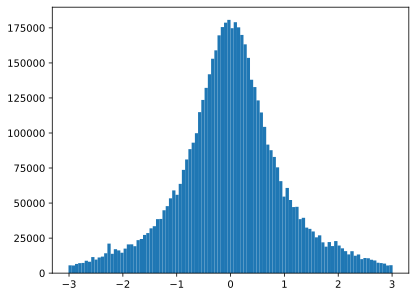

In [27]:
plt.hist(np.tan(df['eta']/2), bins=100)
plt.show()

In [20]:
dfc = add_four_vector(dfc)

top_masses = []
W_masses = []

for event_number, subdf in dfc.groupby("eventNumber"):
    mt1, mt2, mW1, mW2 = reconstruct_top_mass(subdf)
    top_masses.append(mt1)
    top_masses.append(mt2)
    W_masses.append(mW1)
    W_masses.append(mW2)

NameError: name 'add_four_vector' is not defined

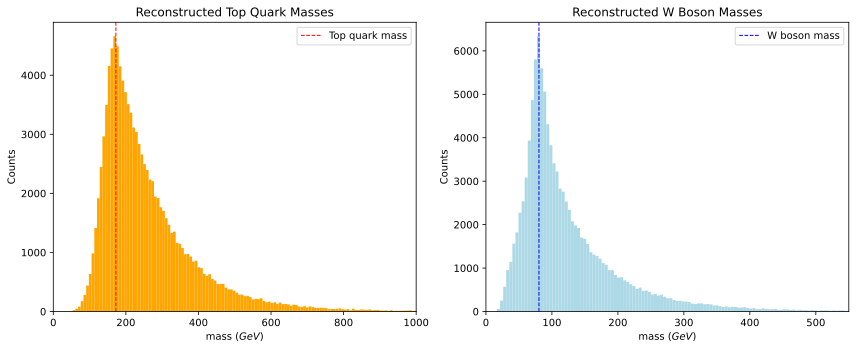

In [132]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(top_masses, bins=300, color='orange')
axes[0].set_title('Reconstructed Top Quark Masses')
axes[0].set_xlabel(r'mass ($GeV$)')
axes[0].set_ylabel('Counts')
axes[0].set_xlim(0, 1000)
axes[0].axvline(x=172.5, color='r', linestyle='--', lw=1, label='Top quark mass')
axes[0].legend()

axes[1].hist(W_masses, bins=400, color='lightblue')
axes[1].set_title('Reconstructed W Boson Masses')
axes[1].set_xlabel(r'mass ($GeV$)')
axes[1].set_ylabel('Counts')
axes[1].set_xlim(0, 550)
axes[1].axvline(x=80.36, color='b', linestyle='--', lw=1, label='W boson mass')
axes[1].legend()

fig.tight_layout()
fig.savefig('reco.svg', dpi=300, bbox_inches='tight')

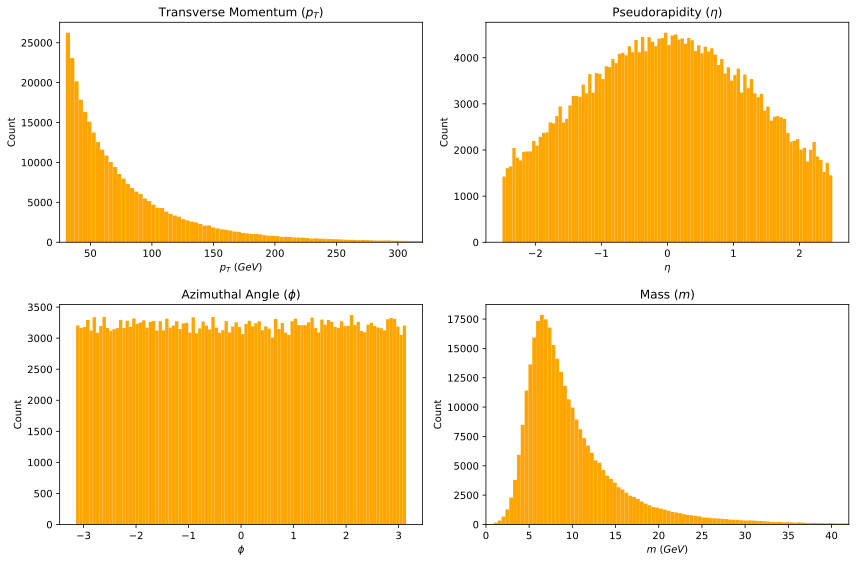

In [95]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(dfc['pt'], bins=500, color='orange')
axes[0, 0].set_title(r'Transverse Momentum ($p_T$)')
axes[0, 0].set_xlabel(r'$p_T$ $(GeV)$')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_xlim(25, 320)

axes[0, 1].hist(dfc['eta'], bins=100, color='orange')
axes[0, 1].set_title(r'Pseudorapidity ($\eta$)')
axes[0, 1].set_xlabel(r'$\eta$')
axes[0, 1].set_ylabel('Count')

axes[1, 0].hist(dfc['phi'], bins=100, color='orange')
axes[1, 0].set_title(r'Azimuthal Angle ($\phi$)')
axes[1, 0].set_xlabel(r'$\phi$')
axes[1, 0].set_ylabel('Count')

axes[1, 1].hist(dfc['mass'], bins=500, color='orange')
axes[1, 1].set_title(r'Mass ($m$)')
axes[1, 1].set_xlabel(r'$m$ $(GeV)$')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_xlim(0, 42)

fig.tight_layout()
fig.savefig('data_visualization.svg', dpi=300, bbox_inches='tight')
plt.show()

In [68]:
# Helper functions
def four_vector(pt, eta, phi, mass):
    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(eta)
    E = np.sqrt(px ** 2 + py ** 2 + pz ** 2 + mass ** 2)
    return E, px, py, pz

def add_four_vector(df):
    df[['E', 'px', 'py', 'pz']] = df.apply(
        lambda row: four_vector(row['pt'], row['eta'], row['phi'], row['mass']),
        axis=1,
        result_type='expand'
    )
    return df

def recover(df):
    # Recover pt, eta, mass
    df['pt'] = np.exp(df['log(pt)'])
    df['eta'] = 2 * np.arctan(df['tan(eta/2)'])
    df['mass'] = np.exp(df['log(mass)'])
    df['phi'] = np.arctan2(df['cos(phi)'], df['sin(phi)'])
    
    # Drop helper columns
    cols = ['log(pt)', 'tan(eta/2)', 'log(mass)', 'cos(phi)', 'sin(phi)']
    df = df.drop(columns=cols)
    return df

In [144]:
from scipy.stats import gaussian_kde, norm

def fit_normal_plot(tm, 
                    tm_test, 
                    bins, 
                    counts, 
                    bins_test, 
                    counts_test, 
                    p=0.5, 
                    show_1_sigma=True, 
                    xlim=(0, 1400)
                   ):
    
    top_masses = np.array(tm)
    top_masses_test = np.array(tm_test)
    
    lg = float(bins[np.argmax(counts)])
    rg = float(bins[np.argmax(counts) + 1])
    
    lt = float(bins_test[np.argmax(counts_test)])
    rt = float(bins_test[np.argmax(counts_test) + 1])
    
    ct = (lt + rt) / 2
    cg = (lg + rg) / 2
    
    nbins=150
    
    mu_t, sigma_t, tm_t = fit_normal(tm_test, ct, p=p)
    mu_g, sigma_g, tm_g = fit_normal(tm, cg, p=p)

    print(mu_g)
    
    left = min(np.min(tm_t), np.min(tm_g))
    right = max(np.max(tm_t), np.max(tm_g))
    x = np.linspace(0, 1400, 10000)
    
    k=p-0.1
    pdf_t = k * norm.pdf(x, loc=mu_t, scale=sigma_t)
    pdf_g = k * norm.pdf(x, loc=mu_g, scale=sigma_g)
    
    # plt.figure(figsize=(9, 7))
    
    plt.plot(x, pdf_t, color='r', label='Test')
    plt.plot(x, pdf_g, color='g', label='Generated')
    
    plt.hist(tm, bins=bins, density=True, histtype='step', linestyle='--', alpha=0.5, label='Generated')
    plt.hist(tm_test, bins=bins, density=True, histtype='step', alpha=0.5, label='Test')
    
    plt.axvline(x=mu_t, color='r', label='truth mode')
    plt.axvline(x=mu_g, color='g', label='generated mode')
    
    s = '--'

    if show_1_sigma:
        plt.axvline(x=mu_t-sigma_t, color='r', linestyle=s, label=f'truth 1σ')
        plt.axvline(x=mu_t+sigma_t, color='r', linestyle=s)
        
        plt.axvline(x=mu_g-sigma_g, color='g', linestyle=s, label=f'gen 1σ')
        plt.axvline(x=mu_g+sigma_g, color='g', linestyle=s)
    
    plt.title(f'{p * 100}% nearest points around mode')
    plt.xlim(xlim)
    plt.xlabel('GeV')
    plt.ylabel('density')
    plt.legend()
    plt.savefig('TopMass_EventsEqual6j_Gen_vs_Tr_FitNormal.svg', dpi=300, bbox_inches='tight')
    plt.show()

def estimate_mode_kde(x, xlim=None, gridsize=5000):
    x = np.asarray(x)
    if xlim is None:
        xlim = (x.min(), x.max())
    grid = np.linspace(xlim[0], xlim[1], gridsize)
    kde = gaussian_kde(x)
    y = kde(grid)
    mode = grid[np.argmax(y)]
    return mode
    
def fit_normal_kde_core(x, p=0.6, xlim=None):
    x = np.asarray(x)
    mode = estimate_mode_kde(x, xlim=xlim)
    dist = np.abs(x - mode)
    k = int(p * len(x))
    idx = np.argsort(dist)[:k]
    core = x[idx]
    mu, sigma = norm.fit(core)
    return mu, sigma, core, mode

In [69]:
print(f'df_train shape:{df_train.shape}')
print(f'df_test shape:{df_test.shape}')
print(f'df columns:{list(df_train.columns)}')
print(f'df_cond_train shape:{df_cond_train.shape}')
print(f'df_cond_test shape:{df_cond_test.shape}')
print(f'df_cond columns:{list(df_cond_train.columns)}')

df_train shape:(256494, 8)
df_test shape:(64128, 8)
df columns:['pt', 'eta', 'phi', 'mass', 'zb', 'zc', 'ztau', 'eventNumber']
df_cond_train shape:(256494, 5)
df_cond_test shape:(64128, 5)
df_cond columns:['eventNumber', 'pt_truth', 'eta_truth', 'phi_truth', 'm_truth']


In [70]:
C_train = df_cond_train.drop(columns=['eventNumber']).to_numpy().reshape(-1, 6 * 4)
C_test = df_cond_test.drop(columns=['eventNumber']).to_numpy().reshape(-1, 6 * 4)

In [71]:
flow = ConditionalAutoregressiveRationalQuadraticSpline(
    reco_events=X_train,
    truth_events=C_train,
    lr=1e-6,
    weight_decay=5e-5,
    hidden_units=128,
    hidden_layers=3,
    K=12,
    num_bins=16,
    tail_bound=3,
    batch_size=1024,
    shuffle=True,
)

In [72]:
flow.train(max_iter=100, show_progress=True)

Training: 100%|██████████| 100/100 [24:59<00:00, 15.00s/it]


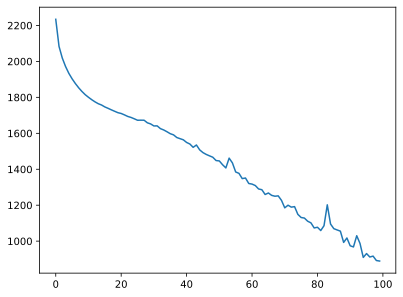

In [73]:
plt.plot(flow.loss_hist)
plt.show()

In [19]:
def recover_prob(df):
    # Recover pb, pc, pu, ptau
    pbpu = np.exp(df['zb'])
    pcpu = np.exp(df['zc'])
    ptaupu = np.exp(df['ztau'])

    den = 1 + pbpu + pcpu + ptaupu

    df['pu'] = 1 / den
    df['pb'] = pbpu / den
    df['pc'] = pcpu / den
    df['ptau'] = ptaupu / den
    
    # Drop helper columns
    cols = ['zb', 'zc', 'ztau']
    df = df.drop(columns=cols)
    
    return df

In [ ]:
X_test_gen = flow.sample(C_test, batch_size=256)
print(X_test_gen.shape)

jets_test_gen = X_test_gen.reshape(-1, 7)

# df_gen_test = pd.DataFrame(jets_test_gen, columns=['log(pt)', 'tan(eta/2)', 'cos(phi)', 'sin(phi)', 'log(mass)'])
# df_gen_test = pd.DataFrame(jets_test_gen, columns=['pt', 'eta', 'phi', 'mass'])
# df_gen_test = pd.DataFrame(jets_test_gen, columns=['pt', 'eta', 'phi', 'mass', 'pb', 'pc', 'pu', 'ptau'])
df_gen_test = pd.DataFrame(jets_test_gen, columns=['pt', 'eta', 'phi', 'mass', 'zb', 'zc', 'ztau'])
# df_gen_test[['pb', 'pc', 'pu', 'ptau','eventNumber']] = df_test[['pb', 'pc', 'pu', 'ptau', 'eventNumber']].to_numpy()
df_gen_test['eventNumber'] = df_test['eventNumber'].to_numpy()

df_gen_test = recover_prob(df_gen_test)
df_gen_test = add_four_vector(df_gen_test)

top_masses_cond = []
W_masses_cond = []

for event_number, subdf in df_gen_test.groupby("eventNumber"):
    mt1, mt2, mW1, mW2 = reconstruct_top_mass(subdf)
    top_masses_cond.append(mt1)
    top_masses_cond.append(mt2)
    W_masses_cond.append(mW1)
    W_masses_cond.append(mW2)

if 'zb' in df_test.columns:
    df_test = recover_prob(df_test)

df_test = add_four_vector(df_test)

top_masses_test = []
W_masses_test = []

for event_number, subdf in df_test.groupby("eventNumber"):
    mt1, mt2, mW1, mW2 = reconstruct_top_mass(subdf)
    top_masses_test.append(mt1)
    top_masses_test.append(mt2)
    W_masses_test.append(mW1)
    W_masses_test.append(mW2)

torch.Size([10688, 42])


In [21]:
def get_bins(x, bin_width=2):
    bins = np.arange(min(x), max(x) + bin_width, bin_width)
    return bins

In [ ]:
# plot reconstructed top masses as a histogram
bins = get_bins(top_masses_cond, bin_width=2)

counts_cond, _, _ = plt.hist(top_masses_cond, bins=bins, density=True, color='orange', histtype='step', linestyle='--', label='Generated')
plt.hist(top_masses_test, bins=bins, density=True, histtype='step', label='Testing')
plt.axvline(x=172.5, color='r', linestyle='--', lw=1, label='True peak')
plt.title('Reconstructed Top Quark Masses')
plt.xlabel('mass (GeV)')
plt.ylabel('probability density')
plt.xlim(0, 500)
# plt.yscale('log')
plt.legend()
# plt.savefig('kine-btags_48d_100epochs_seed=42.svg', dpi=300, bbox_inches='tight')
# plt.savefig('kine-btags_48d_100epochs_zoomin_seed=42.svg', dpi=300, bbox_inches='tight')
plt.show()

print(f'Peak range: {float(bins[np.argmax(counts_cond)]), float(bins[np.argmax(counts_cond) + 1])}')

In [ ]:
top_masses_cond_np = np.array(top_masses_cond)

fit_normal_plot(tm=top_masses_cond_np, 
                tm_test=top_masses_test, 
                bins=bins_cond, 
                counts=counts_cond, 
                bins_test=bins_test, 
                counts_test=counts_test, 
                p=0.5, 
                show_1_sigma=False, 
                xlim=(50, 400)
               )

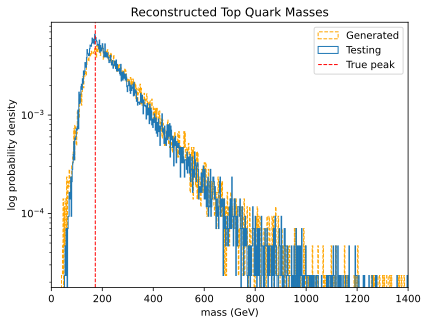

In [59]:
# plot reconstructed top masses as a histogram
plt.hist(top_masses_cond, bins=bins, density=True, color='orange', histtype='step', linestyle='--', label='Generated')
plt.hist(top_masses_test, bins=bins, density=True, histtype='step', label='Testing')
plt.axvline(x=172.5, color='r', linestyle='--', lw=1, label='True peak')
plt.title('Reconstructed Top Quark Masses')
plt.xlabel('mass (GeV)')
plt.ylabel('log probability density')
plt.xlim(0, 1400)
plt.yscale('log')
plt.legend()
plt.savefig('kine-btags_48d_100epochs_log_seed=42.svg', dpi=300, bbox_inches='tight')
# plt.savefig('kine-btags_48d_100epochs_log_zoomin_seed=42.svg', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
ks_stat, _ = ks_2samp(top_masses_test, top_masses_cond)
ks_stat_W, _ = ks_2samp(W_masses_test, W_masses_cond)

print(f"Top mass KS statistic = {ks_stat:.5f}")
print(f"W mass KS statistic = {ks_stat_W:.5f}")

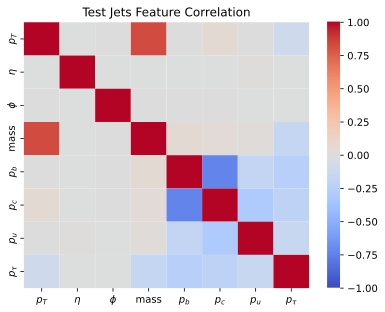

In [58]:
cols1 = [r'$p_T$', r'$\eta$', r'$\phi$', r'mass', 'eventNumber', r'$p_b$', r'$p_c$', r'$p_u$', r'$p_\tau$', 'E', 'px', 'py', 'pz']
cols = [r'$p_T$', r'$\eta$', r'$\phi$', r'mass', r'$p_b$', r'$p_c$', r'$p_u$', r'$p_\tau$']

df_test.columns = cols1
df_gen_test.columns = cols1

corr_test = df_test[cols].corr(method='pearson')
corr_gen  = df_gen_test[cols].corr(method='pearson')

sns.heatmap(corr_test, vmin=-1, vmax=1, cmap='coolwarm')
plt.title('Test Jets Feature Correlation')
plt.savefig('corr_test.svg', dpi=300, bbox_inches='tight')

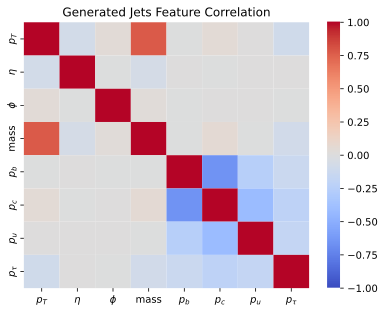

In [59]:
sns.heatmap(corr_gen, vmin=-1, vmax=1, cmap='coolwarm')
plt.title('Generated Jets Feature Correlation')
plt.savefig('corr_gen.svg', dpi=300, bbox_inches='tight')

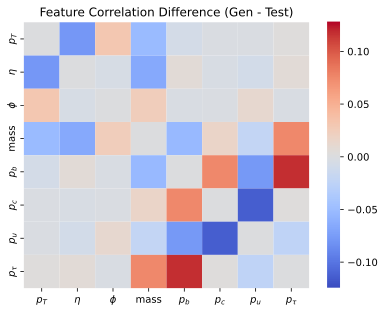

In [61]:
corr_diff = corr_gen - corr_test

sns.heatmap(corr_diff, vmin=np.min(corr_diff)-0.01, vmax=np.max(corr_diff)+0.01, cmap='coolwarm')
plt.title('Feature Correlation Difference (Gen - Test)')
plt.savefig('corr_diff.svg', dpi=300, bbox_inches='tight')

In [34]:
np.array(corr_gen)

array([[ 1.00000000e+00,  3.42860033e-02, -1.37592759e-02,
         7.57274757e-01,  4.32961923e-02,  1.10996543e-02,
        -3.05029596e-03, -1.02419763e-01],
       [ 3.42860033e-02,  1.00000000e+00,  7.09459070e-04,
         2.95204173e-02, -3.80215220e-04,  8.53994292e-03,
        -2.79592786e-03, -6.67532306e-03],
       [-1.37592759e-02,  7.09459070e-04,  1.00000000e+00,
        -1.39221678e-02,  2.84660787e-03, -5.30194382e-04,
        -5.06099292e-03,  4.57489529e-03],
       [ 7.57274757e-01,  2.95204173e-02, -1.39221678e-02,
         1.00000000e+00,  5.12681151e-02, -3.63485530e-03,
        -3.94308520e-03, -9.53109143e-02],
       [ 4.32961923e-02, -3.80215220e-04,  2.84660787e-03,
         5.12681151e-02,  1.00000000e+00, -4.00049439e-01,
        -6.70259786e-01, -2.13868876e-01],
       [ 1.10996543e-02,  8.53994292e-03, -5.30194382e-04,
        -3.63485530e-03, -4.00049439e-01,  1.00000000e+00,
        -2.49172847e-01, -1.81128693e-01],
       [-3.05029596e-03, -2.795927

In [35]:
np.array(corr_test)

array([[ 1.00000000e+00, -3.98374750e-03,  1.96579475e-03,
         8.27461752e-01,  5.62234543e-02,  4.26812252e-03,
        -4.70527305e-03, -1.00157144e-01],
       [-3.98374750e-03,  1.00000000e+00, -2.27981081e-03,
        -4.47307148e-03,  7.61054362e-04,  1.15422198e-02,
        -6.06867003e-03, -2.20436775e-03],
       [ 1.96579475e-03, -2.27981081e-03,  1.00000000e+00,
        -3.19558000e-04,  4.51448216e-03,  2.15117085e-03,
        -7.89129995e-03,  3.62591675e-03],
       [ 8.27461752e-01, -4.47307148e-03, -3.19558000e-04,
         1.00000000e+00,  3.98954855e-02,  1.13655548e-02,
         4.22777540e-02, -1.61486861e-01],
       [ 5.62234543e-02,  7.61054362e-04,  4.51448216e-03,
         3.98954855e-02,  1.00000000e+00, -3.03798793e-01,
        -7.41744569e-01, -2.14146862e-01],
       [ 4.26812252e-03,  1.15422198e-02,  2.15117085e-03,
         1.13655548e-02, -3.03798793e-01,  1.00000000e+00,
        -1.67426603e-01, -1.49095526e-01],
       [-4.70527305e-03, -6.068670

In [62]:
variables = [['pt', 'eta', 'phi', 'mass'], ['E', 'px', 'py', 'pz'], ['pb', 'pc', 'pu', 'ptau']]

def plot_var(dg, dt, xlims=None, nbins=None, htype='step', lw=1, log=False):
    nrows = 3
    fig, axes = plt.subplots(nrows, 4, figsize=(18, 8))

    for i in range(nrows):
        for j in range(4):
            v = variables[i][j]
            
            Vt = dt[v].to_numpy()
            Vg = dg[v].to_numpy()
            
            ks_stat, p_value = ks_2samp(Vt, Vg)
        
            edges = np.histogram_bin_edges(Vt, bins=nbins[i][j], range=(min(Vt.min(), Vg.min()), max(Vt.max(), Vg.max())))
            
            axes[i, j].hist(Vt, bins=edges, label='Testing', alpha=0.5, density=True, 
                     histtype=htype, linewidth=lw, log=log)
            
            axes[i, j].hist(Vg, bins=edges, label='Generated', alpha=0.5, density=True, 
                     histtype=htype, linewidth=lw, linestyle='--', log=log)
        
            scale = 'log' if log else ''
            
            axes[i, j].set_title(f'{v} plot, KS stat = {ks_stat:.2f}')
            axes[i, j].set_xlabel(f'{v}')
            axes[i, j].set_ylabel(f'{scale} probability density')
            axes[i, j].set_xlim(xlims[i][j])

    fig.tight_layout()
    # fig.savefig('kine-btags_48d_100epochs_features_seed=42.svg', dpi=300)
    plt.legend()
    plt.show()

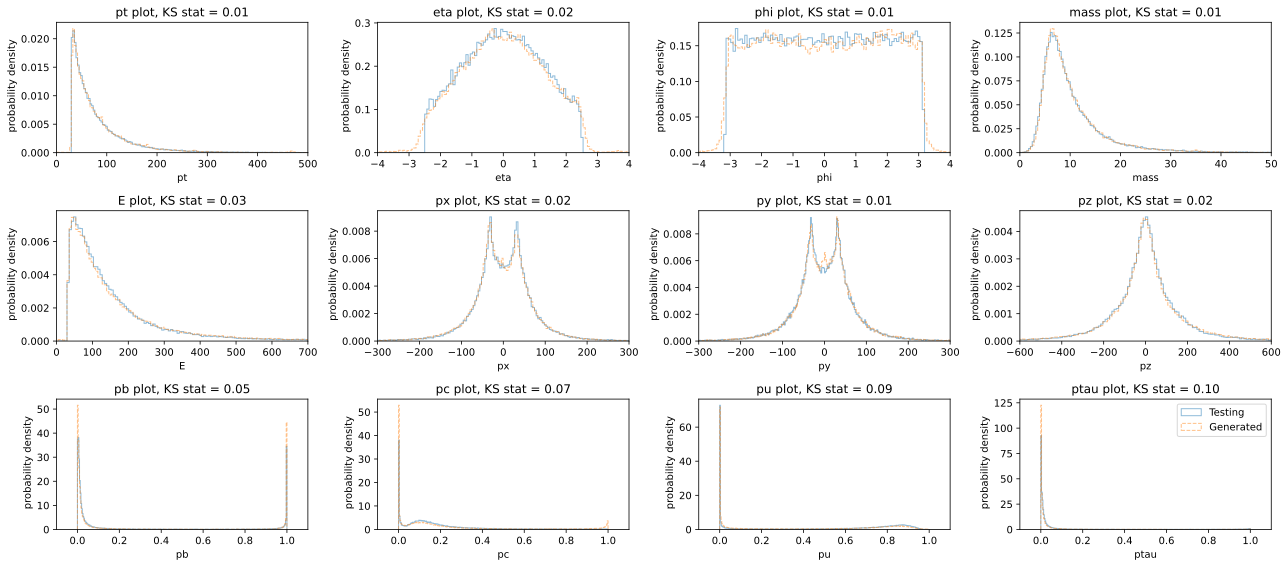

In [63]:
xlims = [[(0, 500), (-4, 4), (-4, 4), (0, 50)], 
         [(0, 700), (-300, 300), (-300, 300), (-600, 600)], 
         [(-0.1, 1.1), (-0.1, 1.1), (-0.1, 1.1), (-0.1, 1.1)]]

nbins = [[500, 150, 200, 600], 
         [2000, 500, 1000, 2000], 
         [300, 300, 300, 300]]

plot_var(dg=df_gen_test, dt=df_test, xlims=xlims, nbins=nbins, htype='step', lw=1, log=False)

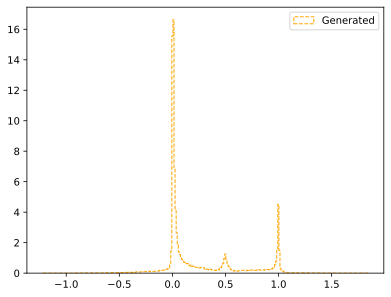

In [26]:
# plot reconstructed top masses as a histogram
counts_cond, bins_cond, _ = plt.hist(df_gen_test['pb'], bins=300, density=True, color='orange', histtype='step', linestyle='--', label='Generated')
# counts_test, bins_test, _ = plt.hist(df_test['pb'], bins=bins_cond, density=True, histtype='step', label='Testing')
# plt.title('pb')
# plt.xlabel('probability')
# plt.xlim(-0.1, 1.1)
# plt.ylim(0, 1)
# plt.yscale('log')
plt.legend()
# plt.savefig('kine-btags_48d_100epochs.svg', dpi=300, bbox_inches='tight')
plt.show()